## 1. Settings

In [24]:
# libraries
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# garbage collection
import gc
gc.enable()

In [4]:
# pandas options
pd.set_option("display.max_columns", None)

In [5]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
# random settings
seed = 42

## 2. Preparation

In [7]:
# dataset
data = "full_cor_2025"

In [8]:
# import data
train = pd.read_csv("../data/prepared/train_" + str(data) + ".csv")
test  = pd.read_csv("../data/prepared/test_"  + str(data) + ".csv")
y     = pd.read_csv("../data/prepared/y_"     + str(data) + ".csv")

In [9]:
# sort data
train = train.sort_values("SK_ID_CURR")
y     = y.sort_values("SK_ID_CURR")

In [10]:
# extract target
y = y["TARGET"]

In [11]:
# exclude features
excluded_feats = ["SK_ID_CURR"]
features = [f for f in train.columns if f not in excluded_feats]

In [12]:
# check dimensions
print(train[features].shape)
print(test[features].shape)

(307511, 1343)
(48744, 1343)


In [13]:
### PARAMETERS

# parallel settings
cores = 10

# learner settings
metric   = "auc"
verbose  = 500
stopping = 300

# CV settings
num_folds = 5
shuffle   = True

# lightGBM
gbm = lgb.LGBMClassifier(n_estimators     = 10000,
                         learning_rate    = 0.01,
                         num_leaves       = 70,
                         colsample_bytree = 0.8,
                         subsample        = 0.9,
                         max_depth        = 7,
                         reg_alpha        = 0.1,
                         reg_lambda       = 0.1,
                         min_split_gain   = 0.01,
                         min_child_weight = 2,
                         random_state     = seed,
                         num_threads      = cores)

## 3. Cross-Validation

### 3.1. All Features

In [14]:
# data partitinoing
folds = StratifiedKFold(n_splits = num_folds, random_state = seed, shuffle = shuffle)

# placeholders
valid_aucs_cv = np.zeros(num_folds) 
test_preds_cv = np.zeros(test.shape[0])
feature_importance_df = pd.DataFrame()

In [15]:
train.head()

,SK_ID_CURR,app_CNT_CHILDREN,app_AMT_INCOME_TOTAL,app_AMT_CREDIT,app_AMT_ANNUITY,app_AMT_GOODS_PRICE,app_REGION_POPULATION_RELATIVE,app_DAYS_BIRTH,app_DAYS_EMPLOYED,app_DAYS_REGISTRATION,app_DAYS_ID_PUBLISH,app_OWN_CAR_AGE,app_FLAG_MOBIL,app_FLAG_EMP_PHONE,app_FLAG_WORK_PHONE,app_FLAG_CONT_MOBILE,app_FLAG_PHONE,app_FLAG_EMAIL,app_CNT_FAM_MEMBERS,app_REGION_RATING_CLIENT,app_REGION_RATING_CLIENT_W_CITY,app_HOUR_APPR_PROCESS_START,app_REG_REGION_NOT_LIVE_REGION,app_REG_REGION_NOT_WORK_REGION,app_LIVE_REGION_NOT_WORK_REGION,app_REG_CITY_NOT_LIVE_CITY,app_REG_CITY_NOT_WORK_CITY,app_LIVE_CITY_NOT_WORK_CITY,app_EXT_SOURCE_1,app_EXT_SOURCE_2,app_EXT_SOURCE_3,app_APARTMENTS_AVG,app_BASEMENTAREA_AVG,app_YEARS_BEGINEXPLUATATION_AVG,app_YEARS_BUILD_AVG,app_COMMONAREA_AVG,app_ELEVATORS_AVG,app_ENTRANCES_AVG,app_FLOORSMAX_AVG,app_FLOORSMIN_AVG,app_LANDAREA_AVG,app_LIVINGAPARTMENTS_AVG,app_LIVINGAREA_AVG,app_NONLIVINGAPARTMENTS_AVG,app_NONLIVINGAREA_AVG,app_YEARS_BUILD_MODE,app_OBS_30_CNT_SOCIAL_CIRCLE,app_DEF_30_CNT_SOCIAL_CIRCLE,app_OBS_60_CNT_SOCIAL_CIRCLE,app_DEF_60_CNT_SOCIAL_CIRCLE,app_DAYS_LAST_PHONE_CHANGE,app_FLAG_DOCUMENT_2,app_FLAG_DOCUMENT_3,app_FLAG_DOCUMENT_4,app_FLAG_DOCUMENT_5,app_FLAG_DOCUMENT_6,app_FLAG_DOCUMENT_7,app_FLAG_DOCUMENT_8,app_FLAG_DOCUMENT_9,app_FLAG_DOCUMENT_10,app_FLAG_DOCUMENT_11,app_FLAG_DOCUMENT_12,app_FLAG_DOCUMENT_13,app_FLAG_DOCUMENT_14,app_FLAG_DOCUMENT_15,app_FLAG_DOCUMENT_16,app_FLAG_DOCUMENT_17,app_FLAG_DOCUMENT_18,app_FLAG_DOCUMENT_19,app_FLAG_DOCUMENT_20,app_FLAG_DOCUMENT_21,app_AMT_REQ_CREDIT_BUREAU_HOUR,app_AMT_REQ_CREDIT_BUREAU_DAY,app_AMT_REQ_CREDIT_BUREAU_WEEK,app_AMT_REQ_CREDIT_BUREAU_MON,app_AMT_REQ_CREDIT_BUREAU_QRT,app_AMT_REQ_CREDIT_BUREAU_YEAR,app_CREDIT_BY_INCOME,app_ANNUITY_BY_INCOME,app_GOODS_PRICE_BY_INCOME,app_INCOME_PER_PERSON,app_PERCENT_WORKED,app_CNT_ADULTS,app_CHILDREN_RATIO,app_ANNUITY LENGTH,app_EXT_SOURCE_MEAN,app_NUM_EXT_SOURCES,app_NUM_DOCUMENTS,app_OWN_CAR_AGE_RATIO,app_DAYS_ID_PUBLISHED_RATIO,app_DAYS_REGISTRATION_RATIO,app_DAYS_LAST_PHONE_CHANGE_RATIO,index_x,buro_CNT_BURO_CLOSED_mean,buro_CNT_BURO_CLOSED_std,buro_CNT_BURO_CLOSED_min,buro_CNT_BURO_CLOSED_max,buro_CREDIT_TYPE_Consumer credit_mean,buro_CREDIT_TYPE_Consumer credit_std,buro_CREDIT_TYPE_Consumer credit_min,buro_CREDIT_TYPE_Consumer credit_max,buro_STATUS_1_mean,buro_STATUS_1_std,buro_STATUS_1_min,buro_STATUS_1_max,buro_CREDIT_CURRENCY_currency 4_mean,buro_CREDIT_CURRENCY_currency 4_std,buro_CREDIT_CURRENCY_currency 4_min,buro_CREDIT_CURRENCY_currency 4_max,buro_CREDIT_TYPE_Real estate loan_mean,buro_CREDIT_TYPE_Real estate loan_std,buro_CREDIT_TYPE_Real estate loan_min,buro_CREDIT_TYPE_Real estate loan_max,buro_AMT_CREDIT_SUM_mean,buro_AMT_CREDIT_SUM_std,buro_AMT_CREDIT_SUM_min,buro_AMT_CREDIT_SUM_max,buro_CREDIT_TYPE_Credit card_mean,buro_CREDIT_TYPE_Credit card_std,buro_CREDIT_TYPE_Credit card_min,buro_CREDIT_TYPE_Credit card_max,buro_AMT_MAX_OVERDUE_RATIO_1_mean,buro_AMT_MAX_OVERDUE_RATIO_1_std,buro_AMT_MAX_OVERDUE_RATIO_1_min,buro_AMT_MAX_OVERDUE_RATIO_1_max,buro_CREDIT_TYPE_Interbank credit_mean,buro_CREDIT_TYPE_Interbank credit_std,buro_CREDIT_TYPE_Interbank credit_min,buro_CREDIT_TYPE_Interbank credit_max,buro_DAYS_CREDIT_mean,buro_DAYS_CREDIT_std,buro_DAYS_CREDIT_min,buro_DAYS_CREDIT_max,buro_CREDIT_TYPE_Mobile operator loan_mean,buro_CREDIT_TYPE_Mobile operator loan_std,buro_CREDIT_TYPE_Mobile operator loan_min,buro_CREDIT_TYPE_Mobile operator loan_max,buro_CREDIT_TYPE_Unknown type of loan_mean,buro_CREDIT_TYPE_Unknown type of loan_std,buro_CREDIT_TYPE_Unknown type of loan_min,buro_CREDIT_TYPE_Unknown type of loan_max,buro_STATUS_2_mean,buro_STATUS_2_std,buro_STATUS_2_min,buro_STATUS_2_max,buro_CREDIT_TYPE_Loan for purchase of shares (margin lending)_mean,buro_CREDIT_TYPE_Loan for purchase of shares (margin lending)_std,buro_CREDIT_TYPE_Loan for purchase of shares (margin lending)_min,buro_CREDIT_TYPE_Loan for purchase of shares (margin lending)_max,buro_CREDIT_DAY_OVERDUE_mean,buro_CREDIT_DAY_OVER

In [16]:
### CROSS-VALIDATION LOOP
for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train, y)):
    
    # data partitioning
    trn_x, trn_y = train[features].iloc[trn_idx].to_numpy(), y.iloc[trn_idx].to_numpy()
    val_x, val_y = train[features].iloc[val_idx].to_numpy(), y.iloc[val_idx].to_numpy()
    
    # train lightGBM
    gbm = gbm.fit(trn_x, trn_y, 
                  eval_set = [(trn_x, trn_y), (val_x, val_y)], 
                  eval_metric = metric, 
                  verbose = verbose, 
                  early_stopping_rounds = stopping)
    
    # save number of iterations
    num_iter_cv = gbm.best_iteration_
    
    # predictions
    valid_preds_cv = gbm.predict_proba(val_x, num_iteration = num_iter_cv)[:, 1]
    valid_aucs_cv[n_fold] = roc_auc_score(val_y, valid_preds_cv)
    test_preds_cv += gbm.predict_proba(test[features], num_iteration = num_iter_cv)[:, 1] / folds.n_splits 
    
    # importance
    fold_importance_df = pd.DataFrame()
    fold_importance_df["Feature"] = features
    fold_importance_df["Importance"] = gbm.feature_importances_
    fold_importance_df["Fold"] = n_fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis = 0)
    
    # print performance
    print("----------------------")
    print("Fold%2d AUC: %.6f" % (n_fold + 1, valid_aucs_cv[n_fold]))
    print("----------------------")
    print("")
    
    # clear memory
    del trn_x, trn_y, val_x, val_y
    gc.collect()
    
# print overall performance    
auc = np.mean(valid_aucs_cv)
print("Cross-Validation AUC score %.6f" % np.mean(valid_aucs_cv))

[LightGBM] [Warning] num_threads is set=10, n_jobs=-1 will be ignored. Current value: num_threads=10
[500]	training's auc: 0.842435	training's binary_logloss: 0.218117	valid_1's auc: 0.782307	valid_1's binary_logloss: 0.238756
[1000]	training's auc: 0.876635	training's binary_logloss: 0.202203	valid_1's auc: 0.788331	valid_1's binary_logloss: 0.236442
[1500]	training's auc: 0.899095	training's binary_logloss: 0.191032	valid_1's auc: 0.790057	valid_1's binary_logloss: 0.235823
[2000]	training's auc: 0.916518	training's binary_logloss: 0.181487	valid_1's auc: 0.790803	valid_1's binary_logloss: 0.235618
----------------------
Fold 1 AUC: 0.790819
----------------------

[LightGBM] [Warning] num_threads is set=10, n_jobs=-1 will be ignored. Current value: num_threads=10
[500]	training's auc: 0.841815	training's binary_logloss: 0.218512	valid_1's auc: 0.790795	valid_1's binary_logloss: 0.236326
[1000]	training's auc: 0.87853	training's binary_logloss: 0.201647	valid_1's auc: 0.797948	valid_

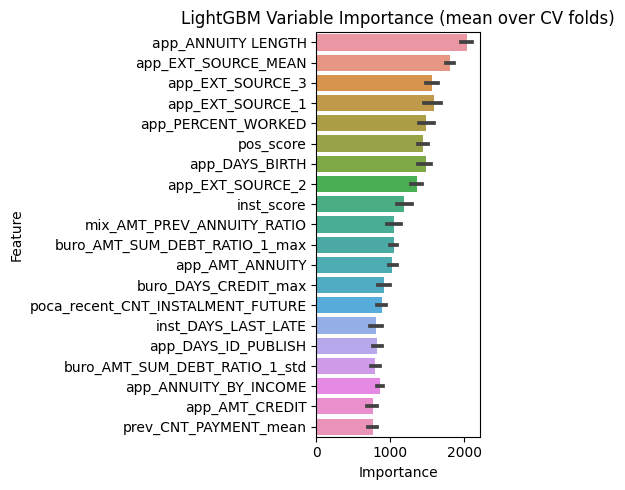

In [34]:
##### VARIABLE IMPORTANCE

# load importance    
top_feats = 20
cols = feature_importance_df[["Feature", "Importance"]].groupby("Feature").mean().sort_values(by = "Importance", ascending = False)[0:top_feats].index
importance = feature_importance_df.loc[feature_importance_df.Feature.isin(cols)]
    
# plot variable importance
plt.figure(figsize = (5, 5))
sns.barplot(x = "Importance", y = "Feature", data = importance.sort_values(by = "Importance", ascending = False))
plt.title('LightGBM Variable Importance (mean over CV folds)')
plt.tight_layout()

# save plot as pdf
plt.savefig("../var_importance.pdf")

### 3.2. Top Features

In [18]:
# keep top features
top = 500
cols = feature_importance_df[["Feature", "Importance"]].groupby("Feature").mean().sort_values(by = "Importance", ascending = False)[0:top].index
importance = feature_importance_df.loc[feature_importance_df.Feature.isin(cols)]
top_features = list(importance.groupby("Feature").Importance.mean().sort_values(ascending = False).index)
# save top features
pd.Series(top_features, name="Feature").to_csv("LightGBM_top_features.csv", index=False)

In [19]:
top_features = pd.read_csv('./LightGBM_top_features.csv')
top_features = top_features['Feature'].tolist()


In [20]:
# check dimensions
print(train[top_features].shape)
print(test[top_features].shape)

(307511, 500)
(48744, 500)


In [37]:
folds = StratifiedKFold(n_splits = num_folds, random_state = seed, shuffle = shuffle)

# placeholders
valid_aucs_cv = np.zeros(num_folds) 
test_preds_cv = np.zeros(test.shape[0])
mean_fpr = np.linspace(0, 1, 100)
tprs = []


[LightGBM] [Warning] num_threads is set=10, n_jobs=-1 will be ignored. Current value: num_threads=10
[500]	training's auc: 0.842293	training's binary_logloss: 0.218167	valid_1's auc: 0.782713	valid_1's binary_logloss: 0.23857
[1000]	training's auc: 0.877676	training's binary_logloss: 0.201793	valid_1's auc: 0.788671	valid_1's binary_logloss: 0.236268
[1500]	training's auc: 0.901835	training's binary_logloss: 0.189805	valid_1's auc: 0.790401	valid_1's binary_logloss: 0.235637
[2000]	training's auc: 0.920294	training's binary_logloss: 0.179616	valid_1's auc: 0.791155	valid_1's binary_logloss: 0.235417
[2500]	training's auc: 0.935453	training's binary_logloss: 0.170181	valid_1's auc: 0.791559	valid_1's binary_logloss: 0.235395
----------------------
Fold 1 AUC: 0.791425
----------------------

[LightGBM] [Warning] num_threads is set=10, n_jobs=-1 will be ignored. Current value: num_threads=10
[500]	training's auc: 0.84109	training's binary_logloss: 0.218762	valid_1's auc: 0.790823	valid_1

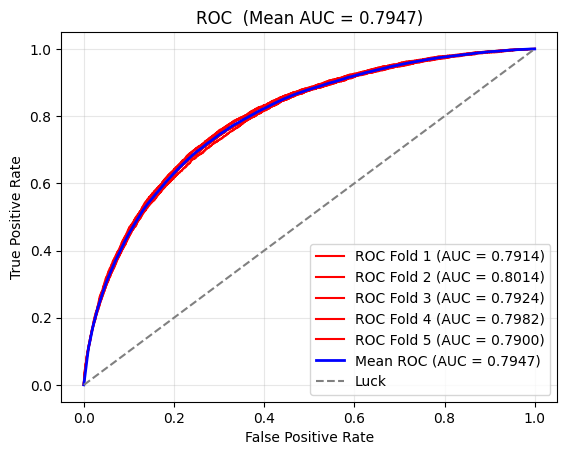

In [41]:
### CROSS-VALIDATION LOOP
for n_fold, (trn_idx, val_idx) in enumerate(folds.split(train, y)):
    
    # data partitioning
    trn_x, trn_y = train[top_features].iloc[trn_idx].to_numpy(), y.iloc[trn_idx].to_numpy()
    val_x, val_y = train[top_features].iloc[val_idx].to_numpy(), y.iloc[val_idx].to_numpy()
    
    # train lightGBM
    gbm = gbm.fit(trn_x, trn_y, 
                  eval_set = [(trn_x, trn_y), (val_x, val_y)], 
                  eval_metric = metric, 
                  verbose = verbose, 
                  early_stopping_rounds = stopping)
    
    # save number of iterations
    num_iter_cv = gbm.best_iteration_
    
    # predictions
    valid_preds_cv = gbm.predict_proba(val_x, num_iteration = num_iter_cv)[:, 1]
    valid_aucs_cv[n_fold] = roc_auc_score(val_y, valid_preds_cv)
    fpr, tpr, _ = roc_curve(val_y, valid_preds_cv)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    
    plt.plot(fpr, tpr, color='r', lw=1.5,label=f'ROC Fold {n_fold + 1} (AUC = {valid_aucs_cv[n_fold]:.4f})')

    test_preds_cv += gbm.predict_proba(test[top_features], num_iteration = num_iter_cv)[:, 1] / folds.n_splits
    
    # print performance
    print("----------------------")
    print("Fold%2d AUC: %.6f" % (n_fold + 1, valid_aucs_cv[n_fold]))
    print("----------------------")
    print("")

    # clear memory
    del trn_x, trn_y, val_x, val_y
    gc.collect()
    
# print overall performance    
auc = np.mean(valid_aucs_cv)
print("Cross-Validation AUC score %.6f" % auc)
mean_tpr = np.mean(tprs, axis=0)
plt.plot(mean_fpr, mean_tpr, color='b', lw=2,label=f'Mean ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label='Luck')
plt.title(f'ROC  (Mean AUC = {auc:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.savefig("../output/ROC.pdf", bbox_inches='tight', dpi=300)
plt.show()


## 4. Submission

In [42]:
# create submission
test["TARGET"] = test_preds_cv
subm = test[["SK_ID_CURR", "TARGET"]]

In [ ]:
# check rank correlation with the best submission
#from scipy.stats import spearmanr
#best = pd.read_csv("../submissions/rmean_top10.csv")
#spearmanr(test.TARGET, best.TARGET)

In [43]:
# export CSV
subm.to_csv("../submissions/lgb.csv", index = False, float_format = "%.8f")

In [ ]:
# no card, old features (560):            0.786941 | 0.783
# no card, new features (694):            0.788893 | 0.783
# with card, new features (1072):         0.790123 | 0.787
# with card and kernel features (1109):   0.790053 | 
# card, kernel, factorize, no na (978):   0.790803 | 
# card, kern, fac, nona, adummy (1193):   0.791321 |
# full data, one-hot ecoding (1844):      0.791850 |
# full data, one-hot, extra sums (2486):  0.791880 | 0.789 
# full, one-hot, sums, buroscore (2501):  0.791761 | 
# full, one-hot, clean, buroscore (1826): 0.791867 |
# last data + ext, age ratios (1828):     0.791808 |
# new app feats, remove weighted (1830):  0.794241 | 0.795
# previous data - top1000 LGB features:   0.794384 |
# select top1500 LGB features:            0.794384 |